## What is a Linear Regression model?

Linear Regression is one of the simplest Machine Learning models. It tries to fit  a straight line f(x) = ax + b to the data points by minimazing the loss function

Epoch    0 | MSE: 1561.6545 | a=0.6437, b=0.9980
Epoch  400 | MSE: 12.6816 | a=0.4189, b=0.9946
Epoch  800 | MSE: 12.6804 | a=0.4189, b=0.9925
Epoch 1200 | MSE: 12.6793 | a=0.4190, b=0.9903
Epoch 1600 | MSE: 12.6782 | a=0.4190, b=0.9882
Epoch 2000 | MSE: 12.6771 | a=0.4190, b=0.9861
Epoch 2400 | MSE: 12.6760 | a=0.4190, b=0.9840
Epoch 2800 | MSE: 12.6748 | a=0.4190, b=0.9819
Epoch 3200 | MSE: 12.6737 | a=0.4190, b=0.9797
Epoch 3600 | MSE: 12.6726 | a=0.4190, b=0.9776
Epoch 4000 | MSE: 12.6715 | a=0.4190, b=0.9755
Epoch 4400 | MSE: 12.6704 | a=0.4191, b=0.9734
Epoch 4800 | MSE: 12.6692 | a=0.4191, b=0.9713

Final parameters: a=0.4191, b=0.9702


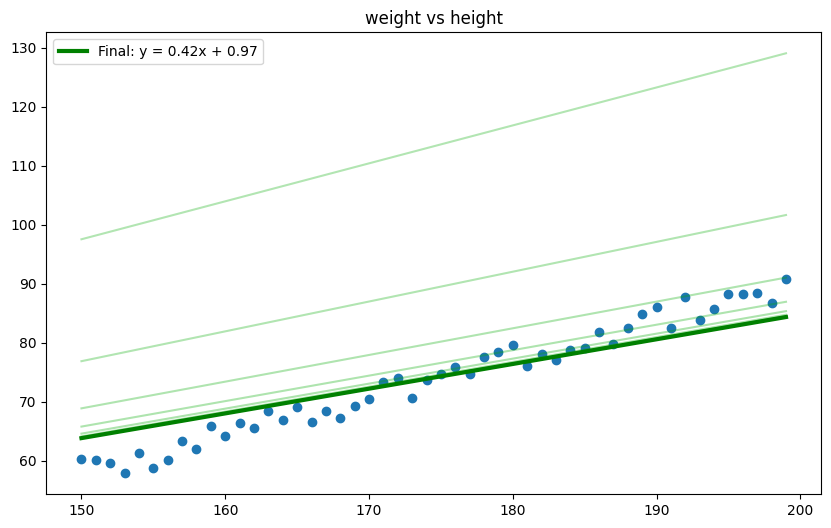

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Create a dataset of people measurements x - height(cm) y - weight(kg)
x = np.arange(150, 200)
y = x * 0.65 + np.random.rand(50) * 5 - 42

# Create a plot
fig, ax = plt.subplots(figsize=(10, 6))
plt.title("weight vs height")

def mse(y_true, y_pred):
    """Computes root mean squared error between two vectors by subtracting predicted values 
    from actual values and squaring them"""
    return sum((y_true - y_pred)**2) / len(y_true)

def mse_derivative(y_true, y_pred):
    return 2 * (y_true - y_pred) / len(y_true)

def update_weights(a, b, x, y_true, learning_rate):
    """Update the weights in the direction of mse loss minimization"""
    # Calculate prediction
    y_pred = a*x + b

    # Calculate gradients
    der_a = 2 / len(x) * np.sum(x * (y_pred - y_true))
    der_b = 2 / len(x) * np.sum(y_pred - y_true)
    a -= learning_rate * der_a
    b -= learning_rate * der_b
    return (a, b)

def lin_reg(x, y_true, n_epochs, learning_rate=1e-5):
    a = 1
    b = 1

    for i in range(n_epochs):
        a, b = update_weights(a, b, x, y_true, learning_rate)
        
        # Plot intermediate fits with increasing opacity
        if i < 100:
            alpha = 0.3 + (i / 100) * 0.6 
            ax.plot(x, a*x+b, color="#00AA00", linewidth=1.5, alpha=alpha)

        # Print every 400 epochs
        if i % 400 == 0:
            y_pred = a*x + b
            error = mse(y_true, y_pred)
            print(f"Epoch {i:4d} | MSE: {error:.4f} | a={a:.4f}, b={b:.4f}")

    return [a, b]


ax.scatter(x, y)

# Train the Linear regression model with a smaller learning rate
a, b = lin_reg(x, y, 5000, learning_rate=1e-5)
y_pred = a*x + b

print(f"\nFinal parameters: a={a:.4f}, b={b:.4f}")

# Plot the final prediction in green
ax.plot(x, y_pred, color="g", linewidth=3, label=f'Final: y = {a:.2f}x + {b:.2f}')
ax.legend()
plt.show()